# Zwierlein lab setup — offline camera, error models, AOD + hardware control

Lab presets for the offline loop **and** the path onto real Spectrum AWG + camera hardware. Run top → bottom.

Package layout this notebook follows:

| Piece                                                      | Where                                         | Role                                                                 |
| ---------------------------------------------------------- | --------------------------------------------- | -------------------------------------------------------------------- |
| `Camera` / `RealArrayCamera` / `OfflineArrayCamera`        | `awg_controller.src.camera`                   | Shared acquire → `detect_occupancy` → `sync(array, recorder=…)`      |
| `GaussianCameraConfig`                                     | `awg_controller.src.camera`                   | Synthetic fluorescence PSF knobs                                     |
| `SessionRecorder` / `GifOptions`                           | `awg_controller.src.session_recorder`         | Stage dumps, `rounds.jsonl`, optional `frames.gif` / `occupancy.gif` |
| `AODSettings` / `RFConverter`                              | `awg_controller.src.awg_control`              | Index-linear site → RF (`f_min`/`f_max` only)                        |
| `HardwareConfig` / `SoftwareConfig` / `atommovrController` | `awg_controller.scripts.atommover_controller` | Closed-loop card + camera driver                                     |
| DDS strategies                                             | `awg_controller.src.dds_strategies`           | `streaming` / `ramp` / `pattern` / `camera_triggered`                |
| `AtomArray` + `ErrorModel`                                 | `atommovr.utils`                              | Occupancy truth + pickup/putdown/lifetime physics                    |
| `travel_duration_s` / phases                               | `atommovr.utils.timing`                       | AWG travel vs sim phase times                                        |
| Optics `um_per_mhz` / FOV                                  | **this notebook**                             | Lab-only; also on `AODSettings` for FOV helpers                      |

`AODSettings.grid_rows/cols` is the trap lattice shared by imaging, algorithms, RF, and the offline camera. §6 shows how these presets plug into real hardware.


In [10]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

_REPO = Path.cwd()
if str(_REPO) not in sys.path:
    sys.path.insert(0, str(_REPO))

from atommovr.utils.core import Configurations, PhysicalParams
from atommovr.utils.errormodels import UniformVacuumTweezerError, ZeroNoise
from atommovr.utils.timing import all_phase_duration_s, travel_duration_s
from awg_controller.scripts.atommover_controller import (
    HardwareConfig,
    SoftwareConfig,
    atommovrController,
)
from awg_controller.src.awg_control import (
    AODSettings,
    RFConverter,
    validate_hardware_limits,
)
from awg_controller.src.camera import (
    Camera,
    GaussianCameraConfig,
    OfflineArrayCamera,
    RealArrayCamera,
)
from awg_controller.src.dds_strategies import STRATEGY_REGISTRY, get_strategy
from awg_controller.src.session_recorder import GifOptions, SessionRecorder

# Shared lattice (2-ch DDS: ≤16 rows × ≤5 cols)
ROWS, COLS = 14, 14

print("imports ok")
print(f"Camera ABC subclasses: {[c.__name__ for c in Camera.__subclasses__()]}")
print(f"DDS strategies: {list(STRATEGY_REGISTRY)}")
print(f"lattice = {ROWS}×{COLS}")

imports ok
Camera ABC subclasses: ['RealArrayCamera', 'OfflineArrayCamera']
DDS strategies: ['streaming', 'ramp', 'pattern', 'camera_triggered']
lattice = 14×14


## 1. Camera + PSF presets (Alvium-like)

Example: Allied Vision Alvium U-1190 — **816×624**, 8-bit mono. Atoms ≈ bright Gaussians on residual background.

**Scaling:** pixel lattice spacing is set by `image_shape` + `min_spacing_px` (`GaussianCameraConfig.resolve_shape`). Physical trap spacing is `PhysicalParams.spacing` (m).

Both `OfflineArrayCamera` and `RealArrayCamera` inherit `Camera.detect_occupancy` (blob → rotate → `fit_grid_and_assign`). Stage dumps happen when the controller calls `camera.sync(array, recorder=…)` — the recorder is **not** a camera property.


frame shape=(624, 816), dtype=uint8, max=191
resolved shape for 14×14: (624, 816)
occupancy (truth) = 119 / 196, detected = 119


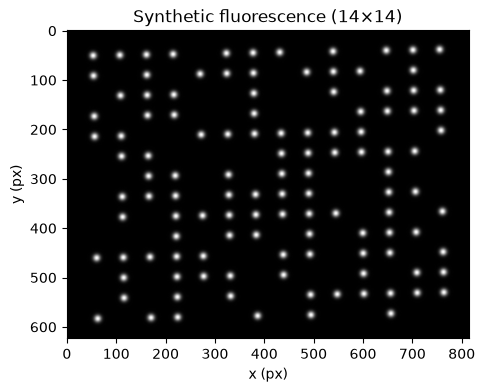

In [11]:
lab_camera = GaussianCameraConfig(
    image_shape=(624, 816),  # (H, W), 8-bit mono
    sigma_px=5,
    peak_counts=180.0,
    background=12.0,  # residual scatter to minimize optically
    noise_level=0.015,
    min_spacing_px=24.0,
    angle=1,
    dtype=np.uint8,
)

offline_preview = OfflineArrayCamera(
    (ROWS, COLS),
    image_generator=lab_camera,
    physical_params=PhysicalParams(loading_prob=0.6, spacing=5e-6),
    seed=42,
)
frame = offline_preview.acquire()
occ_det = offline_preview.detect_occupancy(frame)
print(f"frame shape={frame.shape}, dtype={frame.dtype}, max={frame.max()}")
print(f"resolved shape for {ROWS}×{COLS}: {lab_camera.resolve_shape((ROWS, COLS))}")
print(
    f"occupancy (truth) = {offline_preview.occupancy.sum()} / {ROWS * COLS}, "
    f"detected = {int(occ_det.sum())}"
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(frame, cmap="gray", origin="upper")
ax.set_title(f"Synthetic fluorescence ({ROWS}×{COLS})")
ax.set_xlabel("x (px)")
ax.set_ylabel("y (px)")
plt.show()

## 2. Error-model / timing ballparks

These must be measured on the apparatus. Starting points (vacuum lifetime often 10³–10⁴ s; pickup/putdown depend on trap depth / laser power — see e.g. Phys. Rev. A 84, 032322).

Timing split (`atommovr.utils.timing`):

- **Travel** — Chebyshev sites × spacing / `AOD_speed` → AWG TIMER / host waits
- **Phases** — pickup / accel / decel / putdown on the `ErrorModel` → sim `evolution_time` only


In [12]:
lab_error = UniformVacuumTweezerError(
    pickup_time=200e-6,  # s — transfer static → moving
    putdown_time=200e-6,  # s — transfer moving → static
    accel_time=12.5e-6,  # s — ramp-up (ballpark)
    decel_time=12.5e-6,  # s — ramp-down
    pickup_fail_rate=0.15,  # measure experimentally
    putdown_fail_rate=0.15,
    lifetime=5e3,  # s — vacuum-limited; tune 1e3–1e4
    seed=0,
)

lab_params = PhysicalParams(
    spacing=5e-6,  # m — lattice pitch
    AOD_speed=0.1,  # µm/µs
    loading_prob=0.65,  # enough atoms for a middle target
    middle_size=[10, 10],  # must fit inside ROWS×COLS
)


# Illustrative 3-site diagonal move for travel timing
class _FakeMove:
    def __init__(self, fr, fc, tr, tc):
        self.from_row, self.from_col, self.to_row, self.to_col = fr, fc, tr, tc


travel_s = travel_duration_s(
    [_FakeMove(0, 0, 3, 2)], lab_params.spacing, lab_params.AOD_speed
)
phase_s = all_phase_duration_s(lab_error)

print(lab_error)
print(f"lifetime={lab_error.lifetime}s, pickup={lab_error.pickup_time * 1e6:.1f}µs")
print(f"middle_size={lab_params.middle_size} (inside {ROWS}×{COLS})")
print(
    f"travel (3×2 Chebyshev) = {travel_s * 1e6:.1f}µs; all phases = {phase_s * 1e6:.1f}µs"
)

UniformVacuumTweezerError
lifetime=5000.0s, pickup=200.0µs
middle_size=[10, 10] (inside 14×14)
travel (3×2 Chebyshev) = 150.0µs; all phases = 425.0µs


## 3. AOD frequency presets

**Pipeline contract:**

1. Imaging: pixels → grid indices (`Camera.detect_occupancy`)
2. RF: those indices → Hz via `f = f_min + i * (f_max - f_min) / (n - 1)`

`AODSettings` only owns frequency endpoints + grid size. Optics slope / FOV stay in §4.


lattice = 14×14
Δf_v = 2.769 MHz/site (bandwidth 36.0 MHz)
Δf_h = 2.769 MHz/site (bandwidth 36.0 MHz)


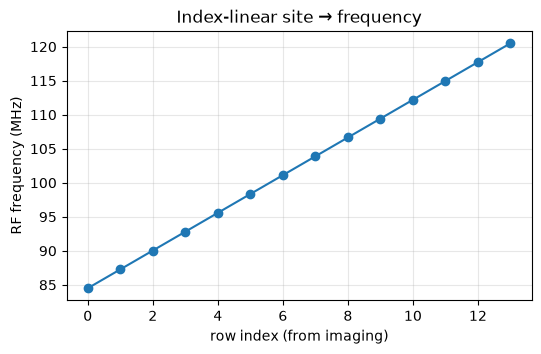

In [13]:
aod = AODSettings(
    grid_rows=ROWS,
    grid_cols=COLS,
    f_min_v=84.5e6,
    f_max_v=120.5e6,
    f_min_h=84.5e6,
    f_max_h=120.5e6,
    alignment="center",
)
assert (aod.grid_rows, aod.grid_cols) == (ROWS, COLS)

bw_v_mhz = (aod.f_max_v - aod.f_min_v) / 1e6
bw_h_mhz = (aod.f_max_h - aod.f_min_h) / 1e6
print(f"lattice = {aod.grid_rows}×{aod.grid_cols}")
print(f"Δf_v = {aod.f_spacing_v / 1e6:.3f} MHz/site (bandwidth {bw_v_mhz:.1f} MHz)")
print(f"Δf_h = {aod.f_spacing_h / 1e6:.3f} MHz/site (bandwidth {bw_h_mhz:.1f} MHz)")

rf = RFConverter(aod, lab_params)
row_idx = np.arange(aod.grid_rows)
freqs = [rf._row_to_freq(i) for i in row_idx]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(row_idx, np.asarray(freqs) / 1e6, "o-")
ax.set_xlabel("row index (from imaging)")
ax.set_ylabel("RF frequency (MHz)")
ax.set_title("Index-linear site → frequency")
ax.grid(True, alpha=0.3)
plt.show()

## 4. Optics note (lab-local)

Theoretical slope: $dx/df = f_\mathrm{obj}\,(f_1/f_2)\,(\lambda/v)$.

Keep the measured `um_per_mhz` here for lab notes. `AODSettings.um_per_mhz` / `fov_um_*` are FOV helpers only — RF still uses `f_min`/`f_max`. If you later measure a different µm/MHz, update both this cell and `aod.um_per_mhz`; do not change the index→Hz map unless the AOD bandwidth changed.


In [14]:
wavelength_m, v_acoustic = 808e-9, 650.0
f1_mm, f2_mm, f_obj_mm = 75.0, 400.0, 28.0
um_per_mhz = (
    (f_obj_mm * 1e-3) * (f1_mm / f2_mm) * (wavelength_m / v_acoustic) * 1e12
)  # m/Hz → µm/MHz
aod.um_per_mhz = um_per_mhz
aod_bandwidth_mhz = 36.0  # typical AOD RF span used for FOV estimate
fov_um = um_per_mhz * aod_bandwidth_mhz

print(f"theoretical um_per_mhz = {um_per_mhz:.3f}")
print(f"AODSettings.um_per_mhz  = {aod.um_per_mhz:.3f}")
print(
    f"FOV ≈ {fov_um:.1f} µm over {aod_bandwidth_mhz:.0f} MHz (fov_um_v={aod.fov_um_v:.1f})"
)
print(f"notebook RF span (V)   = {(aod.f_max_v - aod.f_min_v) / 1e6:.1f} MHz")

theoretical um_per_mhz = 6.526
AODSettings.um_per_mhz  = 6.526
FOV ≈ 234.9 µm over 36 MHz (fov_um_v=234.9)
notebook RF span (V)   = 36.0 MHz


## 5. Offline multi-round smoke test

Uses `atommovrController(camera=offline_cam, recorder=…)`.

- `SessionRecorder` is owned by the **controller**, not the camera
- Each round: `camera.sync(array, recorder=ctrl.recorder)` → `round_XX_acquire/` + `round_XX_detect/`
- Move / RF stats append to `rounds.jsonl`
- Optional GIFs via `GifOptions` → `frames.gif` / `occupancy.gif` (controller calls `finalize()` at end of `run()`)
- Artifacts under `runs/run_YYYYMMDD_HHMMSS/` (gitignored). Omit `recorder=` to disable; use `gif=GifOptions(enabled=False)` to keep dumps without GIFs

**Pick an algorithm + target pattern** in the cell below — every registered single-species algorithm and target `Configurations` pattern works here and in §6 (hardware), since both reuse `ALGORITHM_NAME` / `TARGET_TYPE`. `noise_level=0` for reliable blob detection.

**Multi-round GIF test knobs** (this cell only): high `loading_prob` + elevated pickup/putdown fail rates so `ZeroNoise` does not finish in one shot — aim for ≥5 `detect` frames in `frames.gif` / `occupancy.gif`.

In [ ]:
from atommovr.utils.core import Configurations

# Algorithm: any key in _ALGORITHM_REGISTRY (awg_controller.scripts.atommover_controller)
ALGORITHM_NAME = "Hungarian"
# ALGORITHM_NAME options: "PCFA", "Hungarian", "Tetris", "BalanceAndCompact",
#                          "BCv2", "ParallelLBAP", "ParallelHungarian", "GeneralizedBalance"

# Target pattern: any single-species atommovr.utils.core.Configurations member
TARGET_TYPE = Configurations.MIDDLE_FILL
# TARGET_TYPE options: Configurations.MIDDLE_FILL, .ZEBRA_HORIZONTAL, .ZEBRA_VERTICAL,
#                       .CHECKERBOARD, .Left_Sweep, .RANDOM
# (Configurations.SEPARATE is dual-species only; not used by this single-species controller)

print(f"algorithm = {ALGORITHM_NAME!r}")
print(f"target pattern = {TARGET_TYPE.name}")

In [ ]:
smoke_camera = GaussianCameraConfig(
    image_shape=lab_camera.image_shape,
    sigma_px=lab_camera.sigma_px,
    peak_counts=lab_camera.peak_counts,
    background=lab_camera.background,
    noise_level=0.0,
    min_spacing_px=lab_camera.min_spacing_px,
    angle=lab_camera.angle,
    dtype=lab_camera.dtype,
)

grid = (aod.grid_rows, aod.grid_cols)

# Smoke-test overrides: force ≥5 rearrangement rounds for GIF inspection.
# (ZeroNoise + Hungarian typically fills in ~1 move round → only 2 detect frames.)
smoke_params = PhysicalParams(
    spacing=lab_params.spacing,
    AOD_speed=lab_params.AOD_speed,
    loading_prob=0.75,  # keep surplus atoms under lossy moves
    middle_size=[10, 10],
)
smoke_error = UniformVacuumTweezerError(
    pickup_time=lab_error.pickup_time,
    putdown_time=lab_error.putdown_time,
    accel_time=lab_error.accel_time,
    decel_time=lab_error.decel_time,
    pickup_fail_rate=0.15,  # elevated vs lab — stretches the loop
    putdown_fail_rate=0.15,
    lifetime=1e6,  # suppress lifetime loss for this demo
    seed=7,
)

recorder = SessionRecorder(
    "runs",
    meta={
        "grid": list(grid),
        "target": list(smoke_params.middle_size),
        "algo": ALGORITHM_NAME,
        "seed": 7,
        "note": "multi-round GIF smoke test",
    },
    gif=GifOptions(
        enabled=True,
        sources=("frame", "occupancy"),
        stages=("detect",),  # only post-detection frames in the GIF
        duration_s=1,
        loop=0,
        max_side=512,
        occupancy_cell_px=16,
        auto_write=True,
    ),
)

offline_cam = OfflineArrayCamera(
    grid,
    image_generator=smoke_camera,
    physical_params=smoke_params,
    seed=7,
)

sw = SoftwareConfig(
    algorithm_name=ALGORITHM_NAME,
    max_rounds=5,  # expect ~5 detect frames before fill
    target_type=TARGET_TYPE,
    physical_params=smoke_params,
    error_model=smoke_error,  # ZeroNoise(seed=7) finishes too fast for GIF testing
    aod_settings=aod,
)
hw = HardwareConfig(max_amplitude_v=1.0)  # sim / scope-safe

print(f"session artifacts → {recorder.run_dir}")

with atommovrController(sw, hw, camera=offline_cam, recorder=recorder) as ctrl:
    assert ctrl.camera is offline_cam
    assert ctrl.recorder is recorder
    assert ctrl.grid_shape == grid
    ok = ctrl.run()
    mask = (ctrl.array.target[:, :, 0] > 0).astype(int)
    occ = offline_cam.occupancy

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(mask, cmap="Blues", origin="upper", vmin=0, vmax=1)
axes[0].set_title(f"Target ({TARGET_TYPE.name})")
if occ is not None:
    axes[1].imshow(occ, cmap="Blues", origin="upper")
    filled = int((occ * mask).sum())
    axes[1].set_title(f"Final occ ({filled}/{int(mask.sum())} target sites)")
    print(
        f"success={ok}, atoms={int(occ.sum())}/{occ.size}, "
        f"target_filled={filled}/{int(mask.sum())}"
    )
else:
    print(f"success={ok}")
print(f"rounds.jsonl → {recorder.run_dir / 'rounds.jsonl'}")
print(f"frames.gif → {recorder.run_dir / 'frames.gif'}")
print(f"occupancy.gif → {recorder.run_dir / 'occupancy.gif'}")
plt.tight_layout()
plt.show()

## 6. Hardware control — wiring the lab pipeline

End-to-end on the apparatus:

```text
Alvium (or OfflineArrayCamera)
        │ acquire()
        ▼
Camera.detect_occupancy  →  occupancy grid
        │
        ▼
Algorithm (Hungarian / …)  →  move batches
        │
        ▼
RFConverter  →  AWGBatch (RFRamp list)
        │
        ▼
DDS strategy (streaming | ramp | pattern | camera_triggered)
        │  spcm API
        ▼
Spectrum AWG  →  AOD RF
```

**Safety (do this before connecting the AOD amp):**

- `HardwareConfig.max_amplitude_v` must stay **≤ 2.0 V** (default 1.6 V). Start at **1.0 V** and check on a scope.
- Call `validate_hardware_limits(grid_rows, grid_cols)` at startup.
- Prefer `strategy="ramp"` for transport quality; use `camera_triggered` when the camera TTL fires the card.

Pass a `Camera` via `camera=` (`OfflineArrayCamera` offline, `RealArrayCamera` on the lab). Optional legacy `camera_fn=` is wrapped automatically. Pass `recorder=` on the controller for stage dumps + round JSONL.


In [ ]:
# --- Lab hardware + software configs (reuse §2–§3 presets, §5 algorithm/pattern choice) ---
validate_hardware_limits(aod.grid_rows, aod.grid_cols)
print(f"DDS core check OK for {aod.grid_rows}×{aod.grid_cols}")

hw = HardwareConfig(
    card_paths=["/dev/spcm0"],  # macOS/Linux device node; repeat for multi-card
    max_amplitude_v=1.0,  # start conservative; raise toward ≤1.6 after scope check
    output_load_ohms=50.0,
    trigger_timer_s=0.2,  # TIMER window ≈ expected batch duration
)

tr, tc = lab_params.middle_size
sw = SoftwareConfig(
    # Controller imaging still uses square grid_size for BlobDetection shape;
    # AODSettings carries the authoritative rectangular lattice for RF.
    grid_size=max(ROWS, COLS),
    target_size=min(tr, tc),
    aod_settings=aod,
    physical_params=lab_params,
    max_rounds=5,
    algorithm_name=ALGORITHM_NAME,
    target_type=TARGET_TYPE,
)

print(
    f"hw: cards={hw.card_paths}, amp={hw.max_amplitude_v} V, trg={hw.trigger_timer_s}s"
)
print(f"hw.prefill_count={hw.prefill_count}")
print(
    f"sw: algo={sw.algorithm_name}, target={sw.target_type.name}, "
    f"AOD={sw.aod_settings.grid_rows}×{sw.aod_settings.grid_cols}"
)

In [ ]:
# --- Real camera adapter (replace alvium_grab with your SDK) ---
def alvium_grab() -> np.ndarray:
    """Placeholder: return one mono frame from the lab camera.

    Wire this to Allied Vision / vimba / aravis / your existing grabber.
    For notebook dry-runs we fall back to the offline smoke camera.
    """
    # from vimba import Vimba  # example — not required here
    # ... acquire one frame as np.uint8, shape ~ (624, 816) ...
    raise NotImplementedError("hook up the Alvium SDK here")


def lab_camera_fn() -> np.ndarray:
    """Callable for RealArrayCamera / legacy camera_fn= wrapping."""
    try:
        return alvium_grab()
    except NotImplementedError:
        return offline_cam.acquire()


real_cam = RealArrayCamera(grid, camera_fn=lab_camera_fn)
frame_hw = real_cam.acquire()
occ_hw = real_cam.detect_occupancy(frame_hw)
print(f"RealArrayCamera frame={frame_hw.shape}, detected atoms={int(occ_hw.sum())}")

# --- RF batch preview from §5 rounds.jsonl (or holding tones) ---
holding = rf.holding_config()
print(
    f"holding: {len(holding.ramps)} ramps "
    f"(V cores≈{len(rf.core_map[0])}, H cores≈{len(rf.core_map[1])})"
)

import json as _json

_rounds = recorder.run_dir / "rounds.jsonl"
if _rounds.is_file():
    _rows = [_json.loads(l) for l in _rounds.read_text().splitlines() if l.strip()]
    _move_rows = [r for r in _rows if r.get("n_moves", 0) > 0]
    if _move_rows:
        print(
            f"last logged move round: n_moves={_move_rows[-1]['n_moves']}, "
            f"rf_batches={_move_rows[-1].get('n_rf_batches')}, "
            f"rf_duration_s={_move_rows[-1].get('rf_duration_s')}"
        )
        print(f"  moves sample: {_move_rows[-1].get('moves', [])[:4]}")

In [ ]:
# --- Controller construction (safe: no amp required; skips spcm if missing) ---
# Strategies: "streaming" | "ramp" | "pattern" | "camera_triggered"
strategy = get_strategy("ramp", use_scurve=True, scurve_segments=16)

real_cam_ctrl = RealArrayCamera(grid, camera_fn=lab_camera_fn)
with atommovrController(
    sw, hw, camera=real_cam_ctrl, recorder=recorder, strategy=strategy
) as ctrl:
    print(
        f"controller ready: strategy={ctrl.strategy.name}, "
        f"algo={ctrl.algorithm.__class__.__name__}, "
        f"camera={type(ctrl.camera).__name__}, "
        f"recorder={'on' if ctrl.recorder else 'off'}, "
        f"RF grid={ctrl.rf_converter.settings.grid_rows}×{ctrl.rf_converter.settings.grid_cols}"
    )
    # Live closed loop (scope-check amp first):
    #   ok = ctrl.run()

print("controller context exited cleanly (sim mode OK without spcm)")

### CLI (same presets on the lab machine)

With `spcm` installed and the card present:

```bash
# Scope-first: conservative amp is set in HardwareConfig inside the script (default 1.6 V).
# Override lattice / RF / strategy to match this notebook:
python awg_controller/scripts/atommover_controller.py \
  --algorithm Hungarian \
  --grid-rows 14 --grid-cols 5 \
  --target-rows 6 --target-cols 3 \
  --f-min-v 84.5e6 --f-max-v 120.5e6 \
  --f-min-h 84.5e6 --f-max-h 120.5e6 \
  --strategy ramp \
  --trg-timer 0.2 \
  --card /dev/spcm0 \
```

Bring-up order we recommend:

1. §1–§5 offline (imaging + algorithm + RF batch shapes)
2. Scope on AWG outputs with `max_amplitude_v=1.0`, strategy `ramp` or `streaming`, **no amp → AOD**
3. Connect amp at low gain; verify trap positions vs §3 frequency map
4. Hook `alvium_grab` / `RealArrayCamera` and close the loop
